In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Download Apple stock data from Yahoo Finance
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
close_prices = data['Close']


/tmp/ipython-input-4146376285.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Calculate daily log returns
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()




In [ ]:
# Estimate the mean and standard deviation
mu = log_returns.mean()
sigma = log_returns.std()



In [ ]:
print(f"Mean (μ): {mu}")
print(f"Volatility (σ): {sigma}")

Mean (μ): Ticker
AAPL    0.000963
dtype: float64
Volatility (σ): Ticker
AAPL    0.021137
dtype: float64


In [ ]:
# Simulation parameters
T = 252         # Number of trading days (1 year)
N = 1000        # Number of simulation paths
S0 = close_prices.iloc[-1]  # Last known stock price

# Empty matrix to hold simulated prices
simulations = np.zeros((T, N))

# Run the simulations
for i in range(N):
    prices = [S0]
    for t in range(T - 1):
        z = np.random.normal()
        price = prices[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * z)
        prices.append(price)
    simulations[:, i] = np.array(prices).flatten()  # ✅ Fixed shape mismatch


In [ ]:
simulations

array([[191.13032532, 191.13032532, 191.13032532, ..., 191.13032532,
        191.13032532, 191.13032532],
       [197.54689124, 190.9293864 , 188.93226077, ..., 196.79933647,
        193.3894978 , 198.21606323],
       [198.96101065, 190.77946549, 188.2869704 , ..., 199.38378695,
        193.94929891, 197.52127501],
       ...,
       [268.22934238, 155.77839339, 227.70451397, ..., 234.1295657 ,
        280.11235838, 291.10916606],
       [268.50073693, 156.84985831, 221.69038347, ..., 234.06373881,
        288.42310948, 291.38560526],
       [265.68589638, 155.66617181, 223.52234566, ..., 244.54182204,
        292.64975333, 291.79172342]])

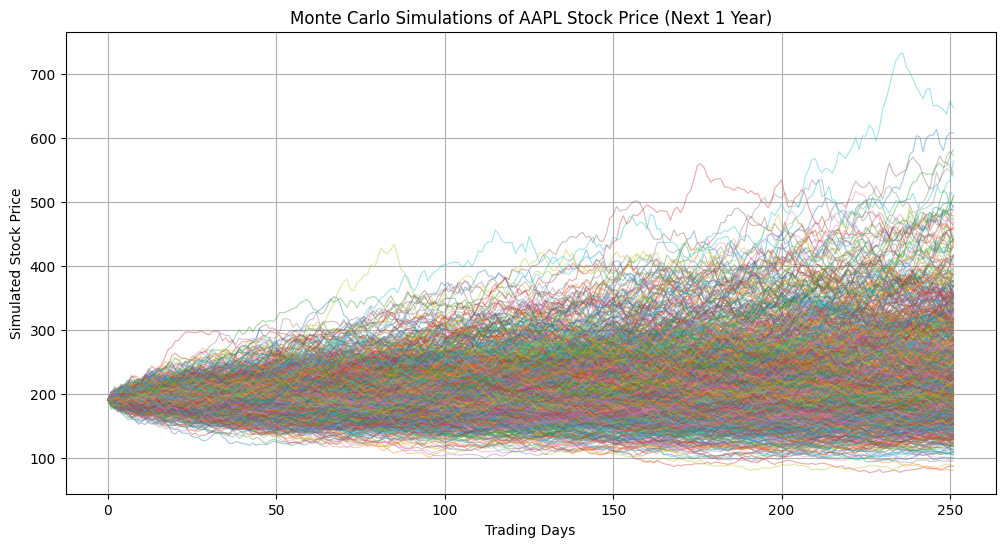

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(simulations, linewidth=0.8, alpha=0.4)
plt.title("Monte Carlo Simulations of AAPL Stock Price (Next 1 Year)")
plt.xlabel("Trading Days")
plt.ylabel("Simulated Stock Price")
plt.grid(True)
plt.show()


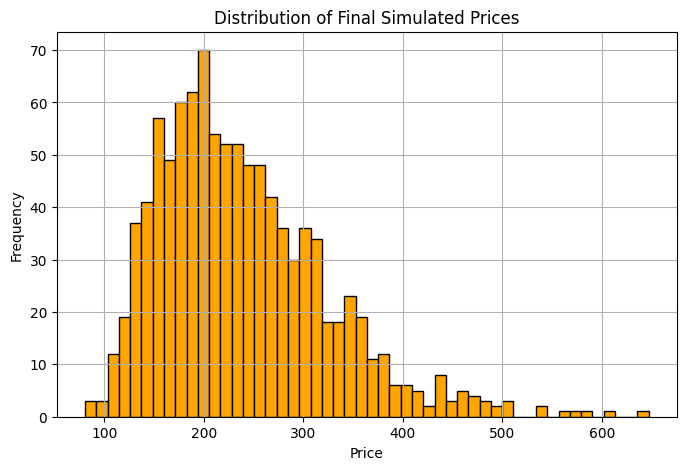

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(simulations[-1, :], bins=50, color='orange', edgecolor='black')
plt.title('Distribution of Final Simulated Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [ ]:
# Final prices after 1 year (last row of simulations)
final_prices = simulations[-1]

# Calculate statistical summaries
expected_price = final_prices.mean()
percentile_5 = np.percentile(final_prices, 5)
percentile_95 = np.percentile(final_prices, 95)

# Print results
print(f" Expected Price After 1 Year: ${expected_price:.2f}")
print(f" 5% Worst Case Price: ${percentile_5:.2f}")
print(f" 95% Best Case Price: ${percentile_95:.2f}")


 Expected Price After 1 Year: $238.63
 5% Worst Case Price: $131.36
 95% Best Case Price: $391.68


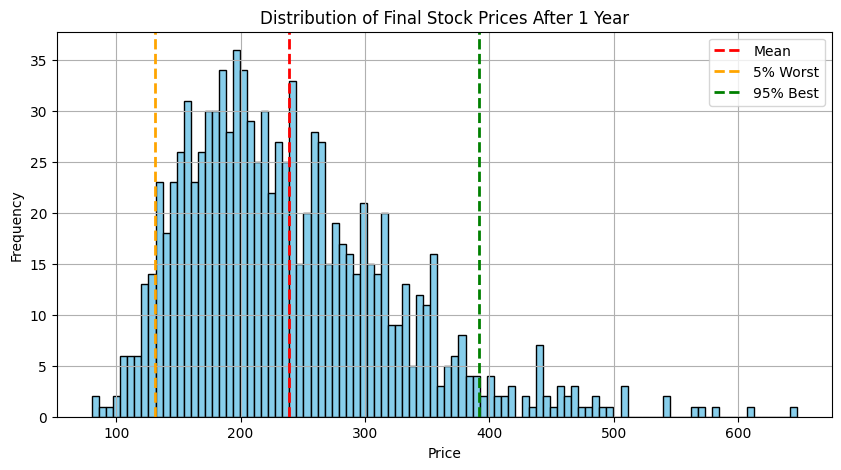

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(final_prices, bins=100, color='skyblue', edgecolor='black')
plt.axvline(expected_price, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(percentile_5, color='orange', linestyle='dashed', linewidth=2, label='5% Worst')
plt.axvline(percentile_95, color='green', linestyle='dashed', linewidth=2, label='95% Best')
plt.title("Distribution of Final Stock Prices After 1 Year")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
VaR_95 = S0 - percentile_5
print(f"💣 95% Value at Risk (1 Year): ${VaR_95:.2f}")


TypeError: unsupported format string passed to Series.__format__

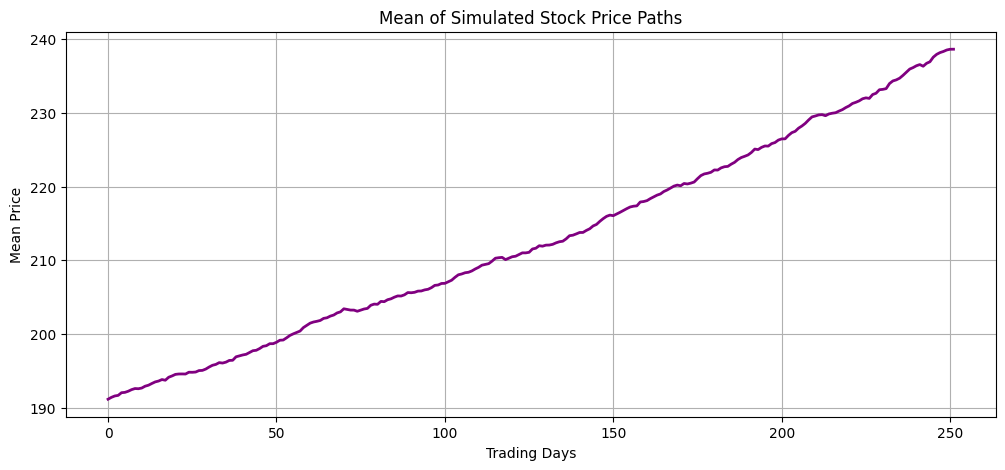

In [ ]:
# Plot mean return path
mean_path = simulations.mean(axis=1)
plt.figure(figsize=(12,5))
plt.plot(mean_path, color='purple', linewidth=2)
plt.title("Mean of Simulated Stock Price Paths")
plt.xlabel("Trading Days")
plt.ylabel("Mean Price")
plt.grid(True)
plt.show()
